============================================
- Title: Assignment 3.1
- Author: Doug Nolan
- Date: 23 Month 2026
- Modified By: Doug Nolan
- Description: This program is working on joins & merges and maths with series

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import random
import numpy as np


# Activity 3.01
## we are getting boston housing data and doing some graphs and finding the amount of houses under 20K


In [4]:
# bring in the data
df = pd.read_csv("/Users/doug/DSC 540/Boston_housing.csv")
df.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [6]:
df.shape
# there are 506 rows and 14 columsn in this data
# likely menas we have listing information on 506 houses across 14 data points

(506, 14)

In [7]:
df1 = df[['CRIM', 'ZN', 'INDUS', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
          'PTRATIO', 'PRICE']]

In [9]:
df1.tail(7)
# look at the last 7 records

,CRIM,ZN,INDUS,RM,AGE,DIS,RAD,TAX,PTRATIO,PRICE
499,0.17783,0.0,9.69,5.569,73.5,2.3999,6,391,19.2,17.5
500,0.22438,0.0,9.69,6.027,79.7,2.4982,6,391,19.2,16.8
501,0.06263,0.0,11.93,6.593,69.1,2.4786,1,273,21.0,22.4
502,0.04527,0.0,11.93,6.120,76.7,2.2875,1,273,21.0,20.6
503,0.06076,0.0,11.93,6.976,91.0,2.1675,1,273,21.0,23.9
504,0.10959,0.0,11.93,6.794,89.3,2.3889,1,273,21.0,22.0
505,0.04741,0.0,11.93,6.030,80.8,2.5050,1,273,21.0,11.9


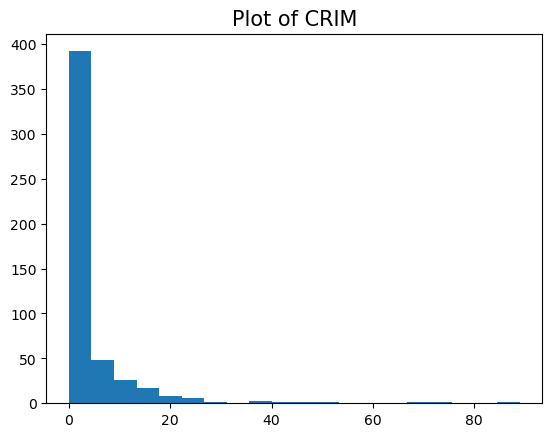

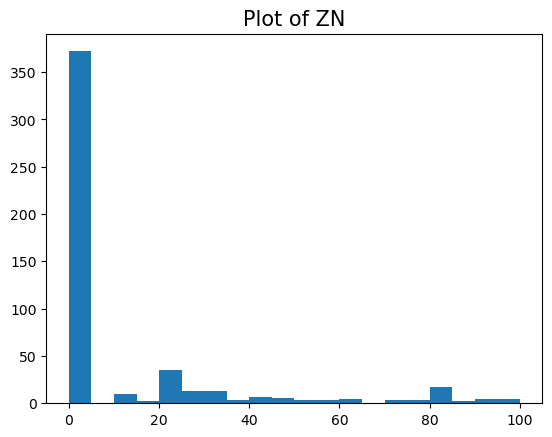

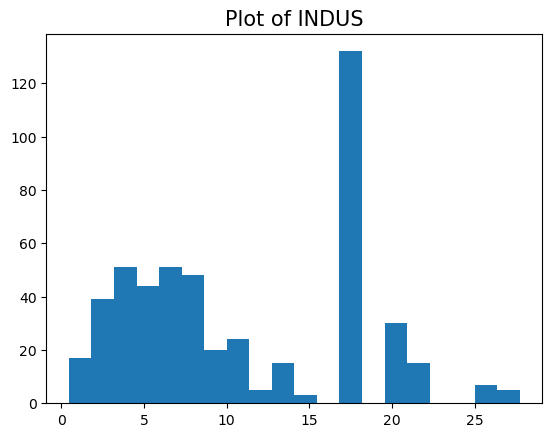

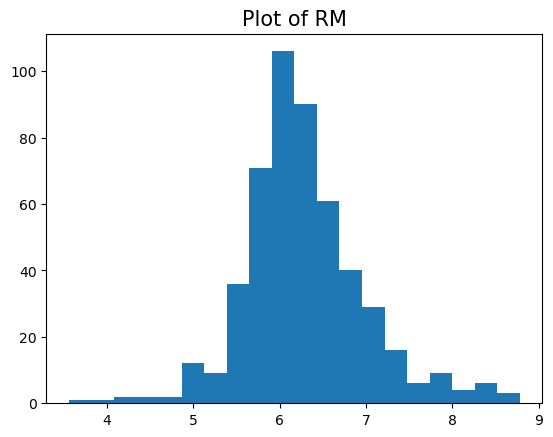

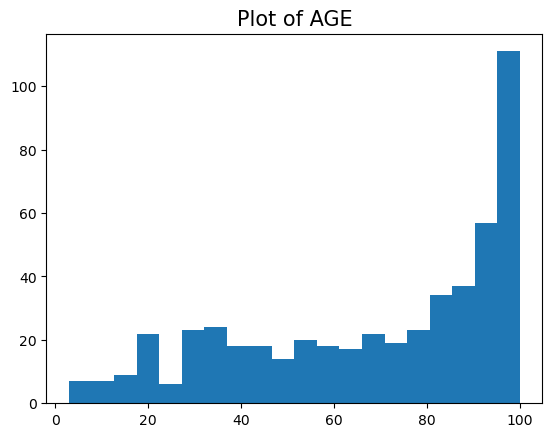

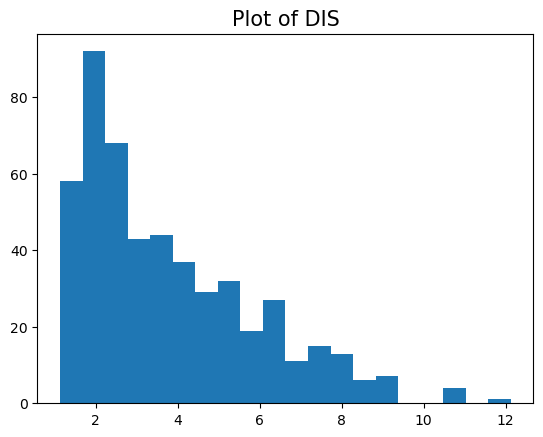

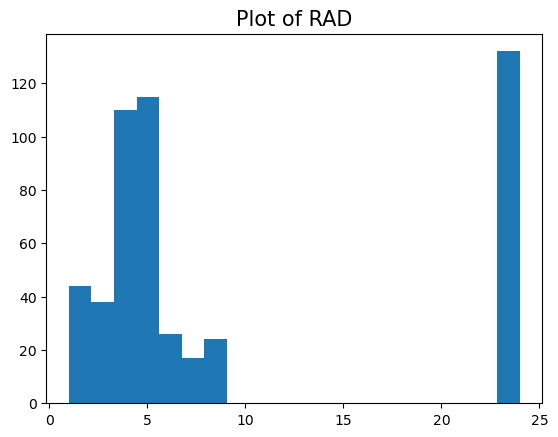

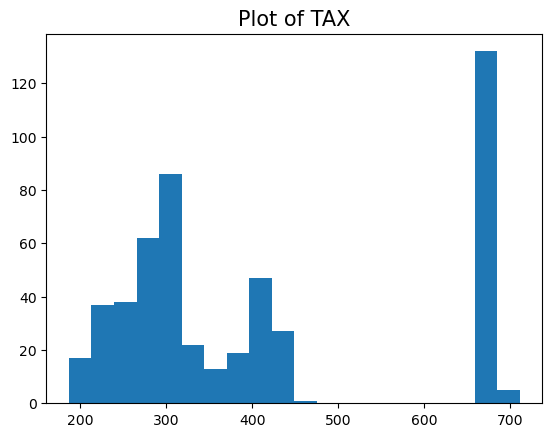

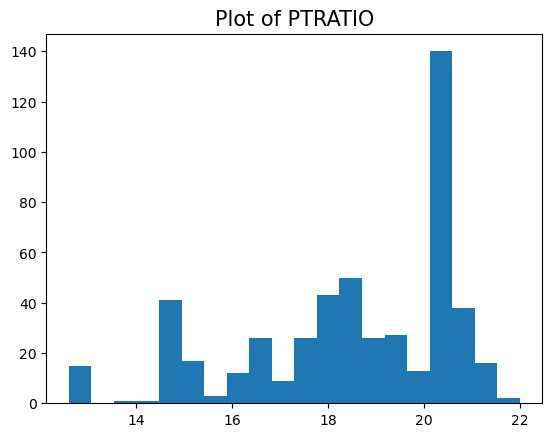

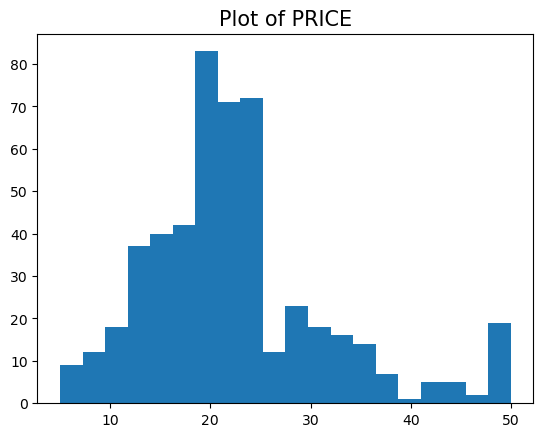

In [11]:
for c in df1.columns:
    plt.title('Plot of '+c, fontsize=15)
    plt.hist(df1[c],bins=20)
    plt.show()
    # plotting a histogram of all the columns across 20 bins. 

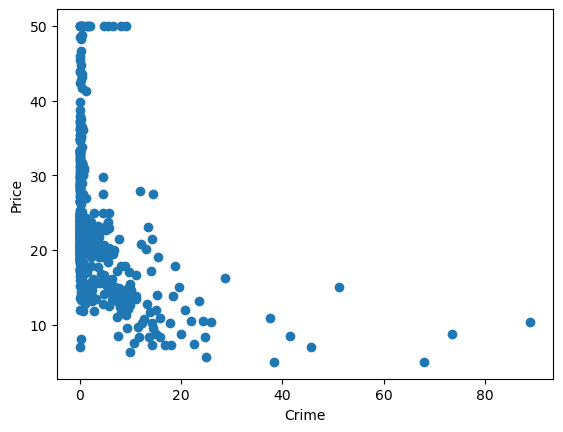

In [13]:
# plot scatterplot of crime against price 
# is crime higher in cheaper house locations?
plt.scatter(df1['CRIM'], df1['PRICE'])
plt.xlabel('Crime')
plt.ylabel('Price')
plt.show()

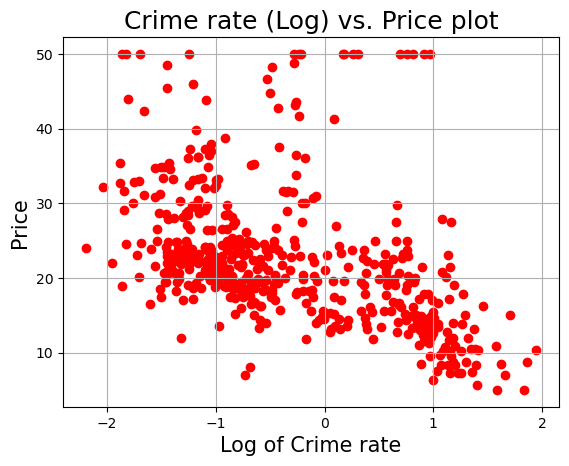

In [14]:
# plot scatter plot of log transformed crime and normal price
plt.scatter(np.log10(df1['CRIM']),df1['PRICE'],c='red')
plt.title("Crime rate (Log) vs. Price plot", fontsize=18)
plt.xlabel("Log of Crime rate",fontsize=15)
plt.ylabel("Price",fontsize=15)
plt.grid(True)
plt.show()

In [17]:
df1['RM'].mean()
# average rm 

np.float64(6.284634387351779)

In [16]:
df1['AGE'].median()
# median age

np.float64(77.5)

In [18]:
df1['DIS'].mean()
# average dis

np.float64(3.795042687747036)

In [19]:
low_price = df1['PRICE']<20
print(low_price)

0      False
1      False
2      False
3      False
4      False
       ...  
501    False
502    False
503    False
504    False
505     True
Name: PRICE, Length: 506, dtype: bool


In [20]:
low_price.mean()
# 41% of the houses are price under 20

np.float64(0.4150197628458498)

In [23]:
pcnt = low_price.mean()*100
print('\nPercentage of house with price <20,000 is : ',pcnt)
# same as above, but prettier


Percentage of house with price <20,000 is :  41.50197628458498


# activity 4.01
## importing and joining 2 different files, 1 csv, 1 txt
## filtering and making graphs

In [25]:
income = pd.read_csv("/Users/doug/DSC 540/adult_income_data.csv")
income.head()

,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,Male,2174,0,40,United-States,<=50K
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,Female,0,0,40,United-States,<=50K


In [27]:
names = []
# create blank list or set, and write the columns names into it to use later
with open("/Users/doug/DSC 540/adult_income_names.txt") as f:
    for line in f:
        f.readline()
        var=line.split(':')[0]
        names.append(var)
names


['age',
 'workclass',
 'fnlwgt',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country']

In [30]:
names.append('Income')
# add one more column name

In [29]:
income = pd.read_csv("/Users/doug/DSC 540/adult_income_data.csv", names = names)
income.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Female,0,0,40,Cuba,<=50K


In [31]:
income.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [32]:
# list of all variables with classes
vars_class = ['workclass', 'education', 'marital-status', 'occupation',
              'relationship', 'sex', 'native-country']

In [33]:
for v in vars_class:
    classes=income[v].unique()
    num_classes = income[v].nunique()
    print('There are {} classes in the \'{}\' column. They are: {}'.format(num_classes,v,classes))
    print('-'*100)

There are 9 classes in the 'workclass' column. They are: <StringArray>
[       ' State-gov', ' Self-emp-not-inc',          ' Private',
      ' Federal-gov',        ' Local-gov',                ' ?',
     ' Self-emp-inc',      ' Without-pay',     ' Never-worked']
Length: 9, dtype: str
----------------------------------------------------------------------------------------------------
There are 16 classes in the 'education' column. They are: <StringArray>
[   ' Bachelors',      ' HS-grad',         ' 11th',      ' Masters',
          ' 9th', ' Some-college',   ' Assoc-acdm',    ' Assoc-voc',
      ' 7th-8th',    ' Doctorate',  ' Prof-school',      ' 5th-6th',
         ' 10th',      ' 1st-4th',    ' Preschool',         ' 12th']
Length: 16, dtype: str
----------------------------------------------------------------------------------------------------
There are 7 classes in the 'marital-status' column. They are: <StringArray>
[        ' Never-married',    ' Married-civ-spouse',              

In [35]:
income.isnull().sum()
# no null values

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
Income            0
dtype: int64

In [36]:
income_subset = income[['age', 'education', 'occupation']]
income_subset.head()
# filtering original df to only show 3 columns

,age,education,occupation
0,39,Bachelors,Adm-clerical
1,50,Bachelors,Exec-managerial
2,38,HS-grad,Handlers-cleaners
3,53,11th,Handlers-cleaners
4,28,Bachelors,Prof-specialty


<Axes: >

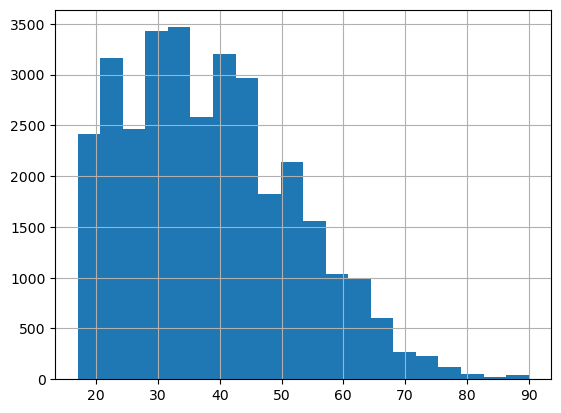

In [37]:
income_subset['age'].hist(bins=20)
# histogram of age, with 20 year age buckets

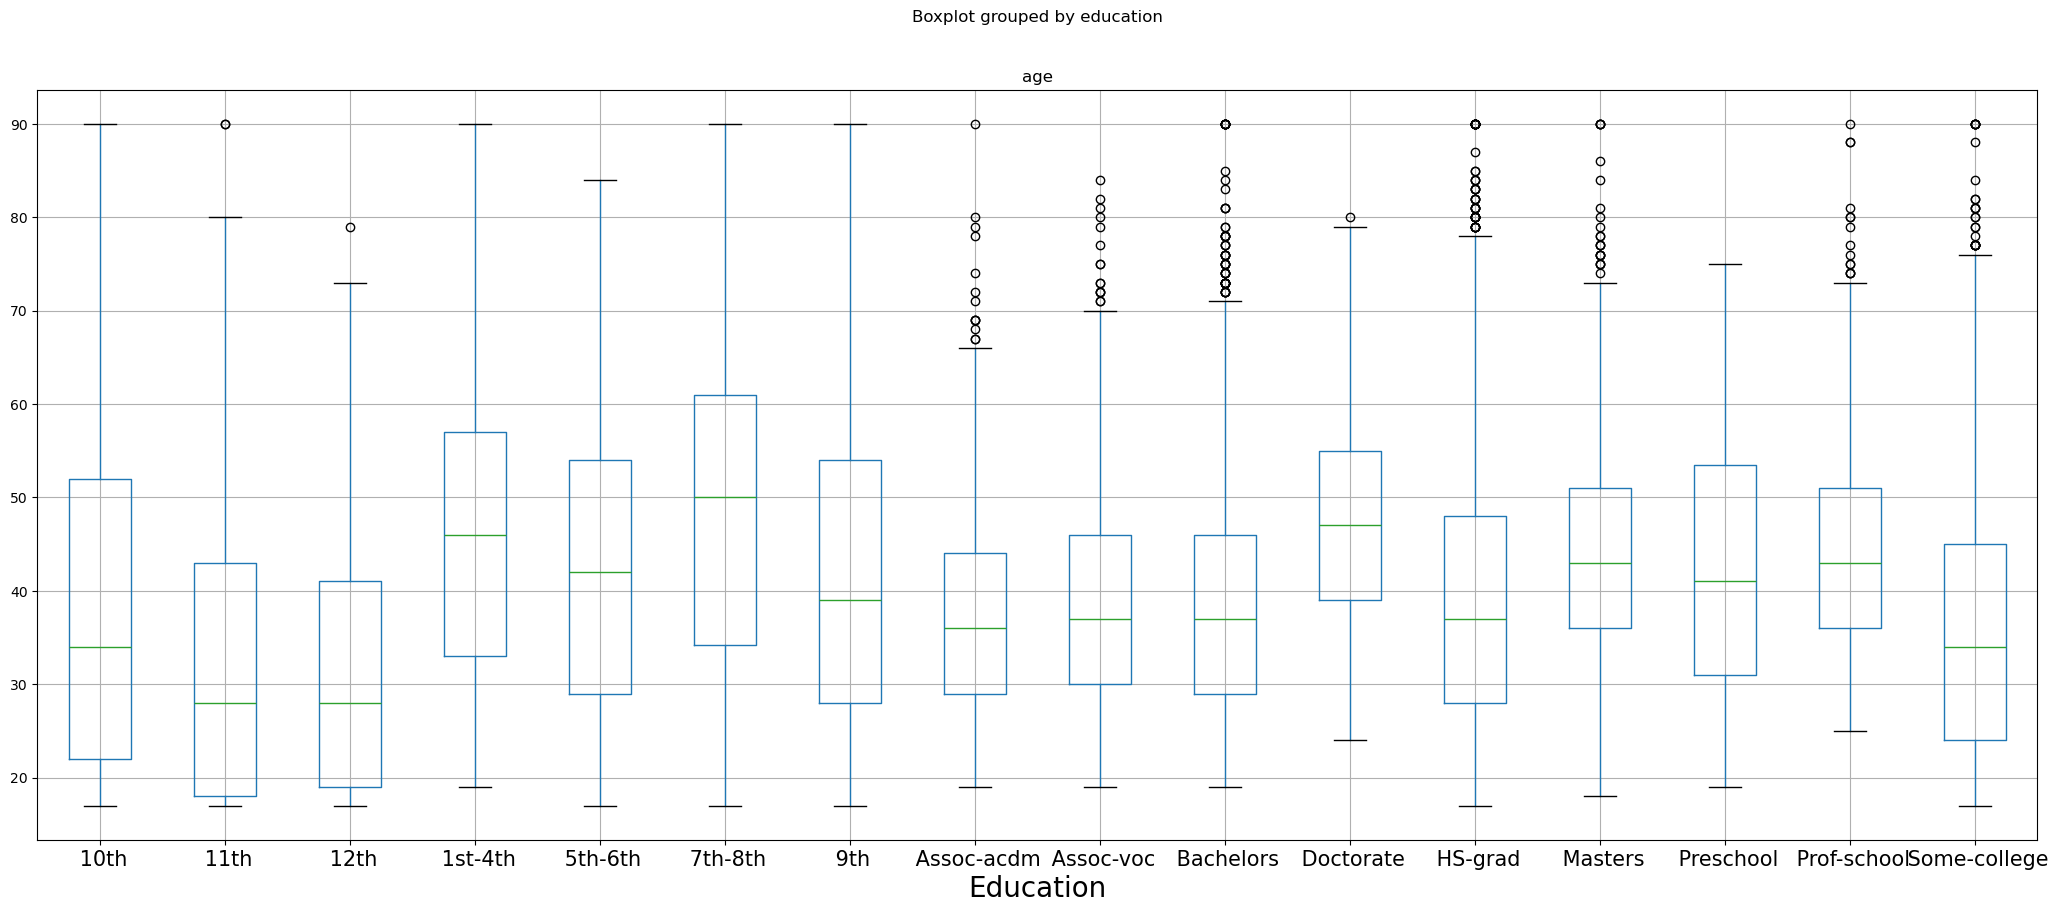

In [39]:
income_subset.boxplot(column='age', by='education', figsize=(25,10))
plt.xticks(fontsize=15)
plt.xlabel('Education', fontsize=20)
plt.show()
# box plot of highest level of education achieved 

In [44]:
income_filtered = income_subset[(income_subset['age']>=30) 
                                 & (income_subset['age']<=50)]
income_filtered.head()

,age,education,occupation
0,39,Bachelors,Adm-clerical
1,50,Bachelors,Exec-managerial
2,38,HS-grad,Handlers-cleaners
5,37,Masters,Exec-managerial
6,49,9th,Other-service


In [45]:
answer_1 = income_filtered.shape[0]
answer_1

16390

In [46]:
print('There are {} people between the age of 30 and 50 in this dataset.'.format(answer_1))

There are 16390 people between the age of 30 and 50 in this dataset.


In [47]:
income_subset.groupby('occupation').describe()['age']

,count,mean,std,min,25%,50%,75%,max
occupation,,,,,,,,
?,1843.0,40.882800,20.336350,17.0,21.0,35.0,61.0,90.0
Adm-clerical,3770.0,36.964456,13.362998,17.0,26.0,35.0,46.0,90.0
Armed-Forces,9.0,30.222222,8.089774,23.0,24.0,29.0,34.0,46.0
Craft-repair,4099.0,39.031471,11.606436,17.0,30.0,38.0,47.0,90.0
Exec-managerial,4066.0,42.169208,11.974548,17.0,33.0,41.0,50.0,90.0
Farming-fishing,994.0,41.211268,15.070283,17.0,29.0,39.0,52.0,90.0
Handlers-cleaners,1370.0,32.165693,12.372635,17.0,23.0,29.0,39.0,90.0
Machine-op-inspct,2002.0,37.715285,12.068266,17.0,28.0,36.0,46.0,90.0
Other-service,3295.0,34.949621,14.521508,17.0,22.0,32.0,45.0,90.0


In [48]:
occupation_stats = income_subset.groupby(
    'occupation').describe()['age']

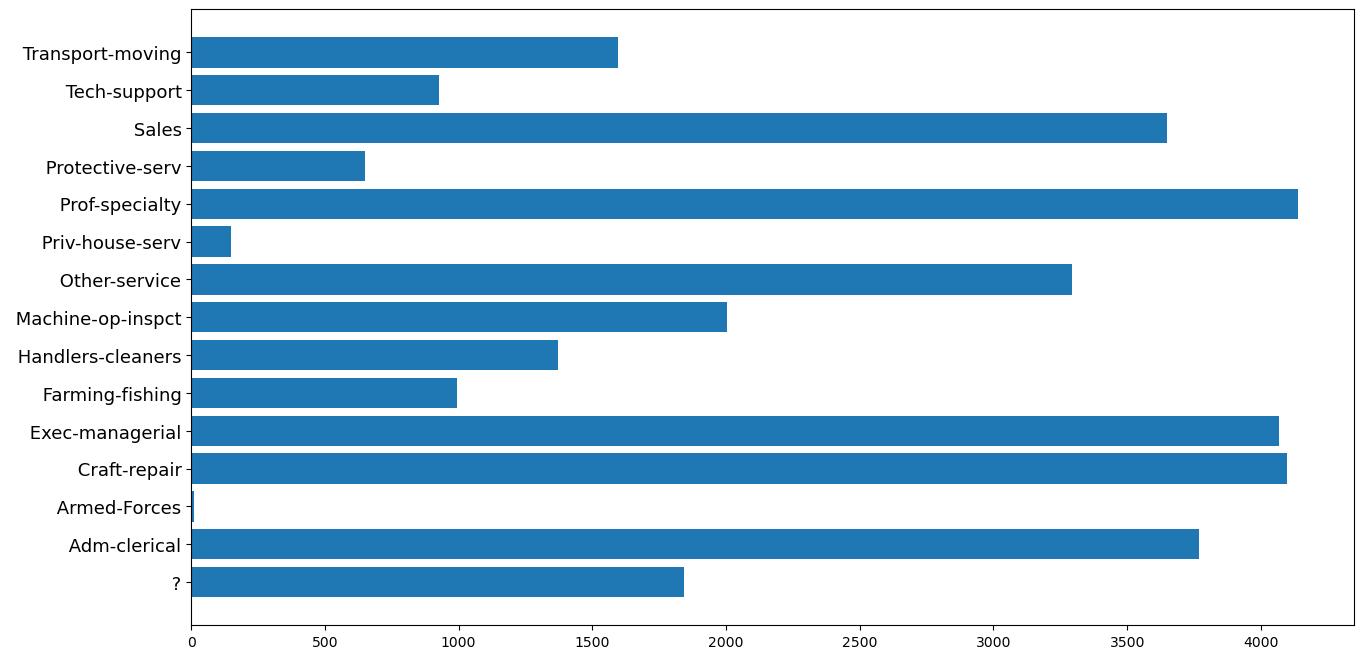

In [49]:
plt.figure(figsize=(15,8))
plt.barh(y=occupation_stats.index,
         width=occupation_stats['count'])
plt.yticks(fontsize=13)
plt.show()
# horizontal bar graph, showing sum of age by jobs

In [50]:
df_1 = income[['age', 'workclass', 'occupation']].sample(5,random_state=10)
df_1.head()

,age,workclass,occupation
11358,58,State-gov,Adm-clerical
10859,23,Local-gov,Prof-specialty
30948,41,Private,Sales
29811,58,Private,Exec-managerial
18408,47,Self-emp-inc,Prof-specialty


In [51]:
df_2 = income[['education', 'occupation']].sample(5,random_state=50)
df_2.head()

,education,occupation
5627,Some-college,Adm-clerical
29006,Assoc-acdm,Exec-managerial
10922,HS-grad,Craft-repair
31192,HS-grad,Craft-repair
20253,Some-college,Prof-specialty


In [53]:
df_merged = pd.merge(df_1, df_2,
                     on = 'occupation', how='inner').drop_duplicates()
df_merged
# join the 2 new dataframes via merge, inner join on same occupations

,age,workclass,occupation,education
0,58,State-gov,Adm-clerical,Some-college
1,23,Local-gov,Prof-specialty,Some-college
2,58,Private,Exec-managerial,Assoc-acdm
3,47,Self-emp-inc,Prof-specialty,Some-college


# 3. rest of homework - fun & math with series's 

In [55]:
s1 = pd.Series(
    [7.3, -2.5, 3.4, 1.5],
    index= ['a', 'c', 'd', 'e'])

print('Series 1:')
print(s1)

Series 1:
a    7.3
c   -2.5
d    3.4
e    1.5
dtype: float64


In [56]:
s2 = pd.Series(
    [-2.1, 3.6, -1.5, 4.-0, 3.1],
    index= ['a', 'c', 'e', 'f', 'g'])

print('\nSeries 2:')
print(s2)


Series 2:
a   -2.1
c    3.6
e   -1.5
f    4.0
g    3.1
dtype: float64


In [57]:
addition = s1 + s2

print('\nSeries 1 + Series 2:')
print(addition) 


Series 1 + Series 2:
a    5.2
c    1.1
d    NaN
e    0.0
f    NaN
g    NaN
dtype: float64


In [58]:
subtraction = s1 - s2

print('\nSeries 1 + Series 2:')
print(subtraction)


Series 1 + Series 2:
a    9.4
c   -6.1
d    NaN
e    3.0
f    NaN
g    NaN
dtype: float64
